Начальные веса: [0. 0.], смещение: 0.0
Результирующие веса: [-1.3358296   0.66278507] смещение: 0.4


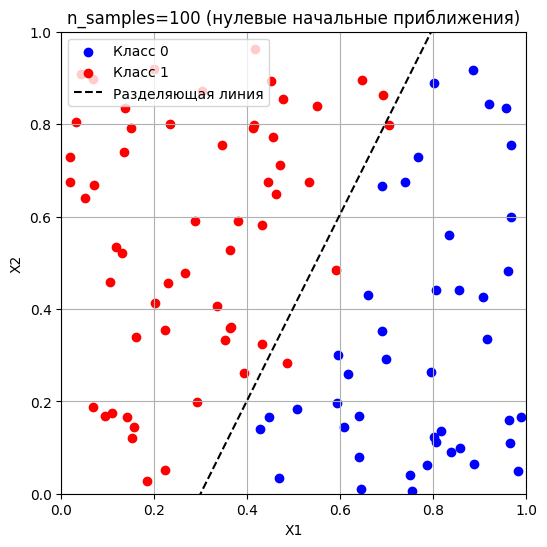

Начальные веса: [0. 0.], смещение: 0.0
Сошлось на итерации 4
Результирующие веса: [-0.03490363  0.08546738] смещение: 0.0


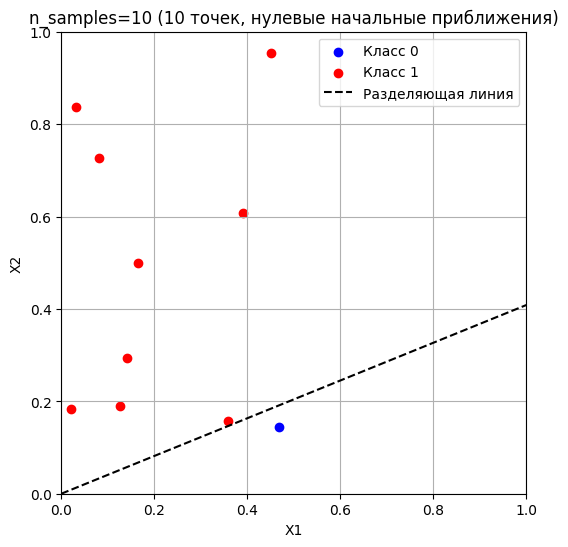

Начальные веса: [ 0.5 -0.5], смещение: 0.2
Сошлось на итерации 4
Результирующие веса: [-0.50798039  0.21438957] смещение: 0.20000000000000004


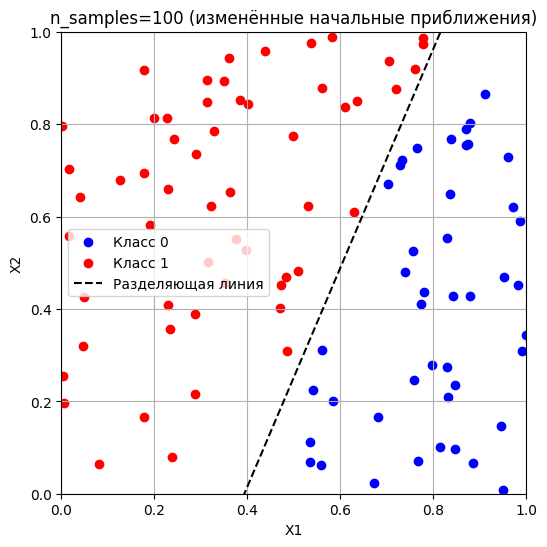

Начальные веса: [ 0.5 -0.5], смещение: 0.2
Сошлось на итерации 5
Результирующие веса: [-0.0227687  0.0808472] смещение: 0.0


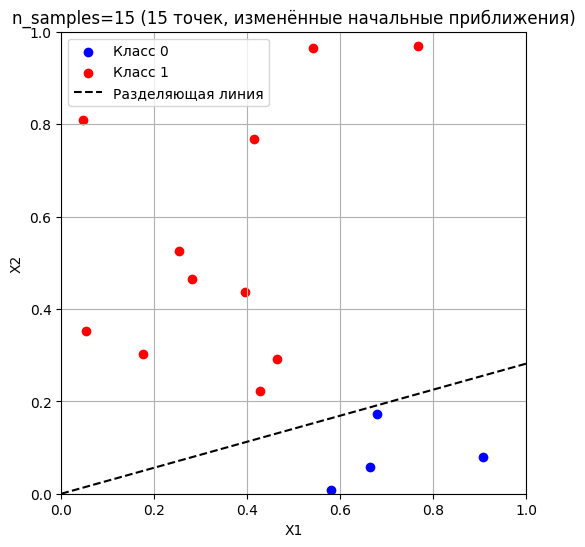

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Функция пороговой активации: если net >= 0, то 1, иначе 0.
def step_activation(net):
    return np.where(net >= 0, 1, 0)

# Функция обучения перцептрона
def train_perceptron(X, y, weights, bias, lr=0.1, max_iter=100):
    n_samples = X.shape[0]
    for iteration in range(max_iter):
        error_count = 0
        for i in range(n_samples):
            net = np.dot(X[i], weights) + bias
            prediction = step_activation(net)
            error = y[i] - prediction
            # Если ошибка, корректируем веса и смещение
            if error != 0:
                weights += lr * error * X[i]
                bias += lr * error
                error_count += 1
        # Если ошибок нет – алгоритм сошелся
        if error_count == 0:
            print(f'Сошлось на итерации {iteration}')
            break
    return weights, bias

# Функция для визуализации результатов: точки и разделяющая линия
def plot_decision_boundary(X, y, weights, bias, title=''):
    plt.figure(figsize=(6,6))
    # Отображаем точки разных классов
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Класс 0')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Класс 1')
    
    # Вычисляем координаты для линии: w1*x + w2*y + bias = 0  =>  y = (-w1*x - bias)/w2
    x_vals = np.linspace(0, 1, 100)
    # Проверяем, чтобы w2 не был нулевым
    if weights[1] != 0:
        y_vals = -(weights[0]*x_vals + bias)/weights[1]
        plt.plot(x_vals, y_vals, 'k--', label='Разделяющая линия')
    else:
        # Если w2 == 0, линия вертикальная: x = -bias/weights[0]
        x_line = -bias/weights[0]
        plt.axvline(x=x_line, color='k', linestyle='--', label='Разделяющая линия')
    
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Генерация исходных данных
def generate_data(n_samples):
    X = np.random.rand(n_samples, 2)
    # Задаём класс: Y = True, если (2*X1 - 0.7) + (-X2 + 0.1) < 0.1, иначе False
    y = (((2*X[:, 0] - 0.7) + (-X[:, 1] + 0.1)) < 0.1).astype(int)
    return X, y

# Основной эксперимент
def experiment(n_samples=100, init_weights=None, init_bias=0.0, lr=0.1, max_iter=100, title_suffix=''):
    X, y = generate_data(n_samples)
    if init_weights is None:
        init_weights = np.zeros(2)  # нулевые начальные веса
    else:
        init_weights = np.array(init_weights, dtype=float)
    bias = init_bias
    print(f"Начальные веса: {init_weights}, смещение: {bias}")
    weights, bias = train_perceptron(X, y, init_weights, bias, lr=lr, max_iter=max_iter)
    print("Результирующие веса:", weights, "смещение:", bias)
    plot_decision_boundary(X, y, weights, bias, title=f"n_samples={n_samples} {title_suffix}")

# --- Эксперименты ---

# 1. Стандартный эксперимент: n_samples = 100, нулевые начальные веса и смещение
experiment(n_samples=100, init_weights=[0,0], init_bias=0.0, title_suffix="(нулевые начальные приближения)")

# 2. Эксперимент с уменьшенным числом точек (например, 10 точек)
experiment(n_samples=10, init_weights=[0,0], init_bias=0.0, title_suffix="(10 точек, нулевые начальные приближения)")

# 3. Эксперимент с другим начальным приближением (например, [0.5, -0.5] и смещение 0.2)
experiment(n_samples=100, init_weights=[0.5, -0.5], init_bias=0.2, title_suffix="(изменённые начальные приближения)")

# 4. Эксперимент с уменьшенным числом точек и другими начальными значениями
experiment(n_samples=15, init_weights=[0.5, -0.5], init_bias=0.2, title_suffix="(15 точек, изменённые начальные приближения)")
